# **Case QuantumFinance - Disciplina NLP - Classificador de chamados**

**Atenção:**
- Leia com atenção o descritivo do trabalho e as orientações do template.
- O trabalho deve ser entregue respeitando a estrutura do arquivo de template em notebook "Template_Trabalho_Final_NLP.ipynb" e compactado no formato .zip. Apenas um arquivo no formato .ipynb deve ser entregue consolidando todo o trabalho.

***Participantes (RM - NOME):***<br>
362209 - Eleric Escaleira Fuzinato<br>
360558 - Douglas Cassiano Rodrigues Paes <br>

###**Crie um classificador de chamados aplicando técnicas de PLN**
---

A **QuantumFinance** tem um canal de atendimento via chat e precisar classificar os assuntos dos atendimentos para melhorar as tratativas dos chamados dos clientes. O canal recebe textos abertos dos clientes relatando o problema e/ou dúvida e depois é direcionado para alguma área especialista no assunto para uma melhor tratativa.​

1. Crie ao menos um modelo classificador de assuntos aplicando técnicas de NLP (PLN), Vetorização (n-grama + métrica) e modelo supervisionado, que consiga classificar através de um texto o assunto conforme disponível na base de dados [1] para treinamento e validação do seu modelo.​

  O modelo precisar atingir um score na **métrica F1 Score superior a 75%**. Utilize o dataset [1] para treinar e testar o modelo, separe o dataset em duas amostras (75% para treinamento e 25% para teste com o randon_state igual a 42).​

2. Utilizar ao menos uma aplicação de modelos com Embeddings usando Word2Vec e/ou LLM´s para criar o modelo classificador com os critérios do item 1.

Fique à vontade para testar e explorar as técnicas de pré-processamento, abordagens de NLP, algoritmos e bibliotecas, mas explique e justifique as suas decisões durante o desenvolvimento.​

**Composição da nota:​**

**50%** - Demonstrações das aplicações das técnicas de PLN (regras, pré-processamentos, tratamentos, variedade de modelos aplicados, aplicações de Embeddings, organização do pipeline, etc.)​

**50%** - Baseado na performance (score) obtida com a amostra de teste no pipeline do modelo campeão (validar com  a Métrica F1 Score). **Separar o pipeline completo do modelo campeão conforme template.​**

O trabalho poderá ser feito em grupo de 2 até 4 pessoas (mesmo grupo do Startup One) e trabalhos iguais serão descontado nota e passível de reprovação.

**[1] = ​https://dados-ml-pln.s3.sa-east-1.amazonaws.com/tickets_reclamacoes_classificados.csv**

**[F1 Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)** com average='weighted'

In [ ]:
# CARREGANDO O DATA FRAME
import pandas as pd
df = pd.read_csv('https://dados-ml-pln.s3.sa-east-1.amazonaws.com/tickets_reclamacoes_classificados.csv', delimiter=';')

# Façam o download do arquivo e utilizem localmente durante os testes

In [ ]:
df.info()

Bom desenvolvimento!

###**Area de desenvolvimento e validações**

Faça aqui as demonstrações das aplicações das técnicas de PLN (regras, pré-processamentos, tratamentos, variedade de modelos aplicados, organização do pipeline, etc.)​

Fique à vontade para testar e explorar as técnicas de pré-processamento, abordagens de NLP, algoritmos e bibliotecas, mas explique e justifique as suas decisões durante o desenvolvimento.​

## 1 Importações gerais

In [1]:
import pandas as pd

import numpy as np
import re
import torch
import matplotlib.pyplot as plt

from unidecode import unidecode
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import f1_score, classification_report

## 2 Importando o dataframe

In [2]:
# Arquivo local (upload do chat)
csv_local = r"tickets_reclamacoes_classificados.csv"

# Observação: separador ';' e há quebras de linha dentro do texto -> engine='python'
df = pd.read_csv(csv_local, sep=';')

df.head()

,id_reclamacao,data_abertura,categoria,descricao_reclamacao
0,3229299,2019-05-01T12:00:00-05:00,Hipotecas / Empréstimos,"Bom dia, meu nome é xxxx xxxx e agradeço se vo..."
1,3199379,2019-04-02T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,Atualizei meu cartão xxxx xxxx em xx/xx/2018 e...
2,3233499,2019-05-06T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,O cartão Chase foi relatado em xx/xx/2019. No ...
3,3180294,2019-03-14T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,"Em xx/xx/2018, enquanto tentava reservar um ti..."
4,3224980,2019-04-27T12:00:00-05:00,Serviços de conta bancária,"Meu neto me dê cheque por {$ 1600,00} Eu depos..."


## 3 Analisando o dataframe

In [3]:
# Dimensões do DataFrame
df.shape

(21072, 4)

In [4]:
# Visualizando as colunas do DataFrame
df.columns

Index(['id_reclamacao', 'data_abertura', 'categoria', 'descricao_reclamacao'], dtype='object')

id_reclamacao           0
data_abertura           0
categoria               0
descricao_reclamacao    0
dtype: int64

categoria
Serviços de conta bancária             5161
Cartão de crédito / Cartão pré-pago    5006
Roubo / Relatório de disputa           4822
Hipotecas / Empréstimos                3850
Outros                                 2233
Name: count, dtype: int64

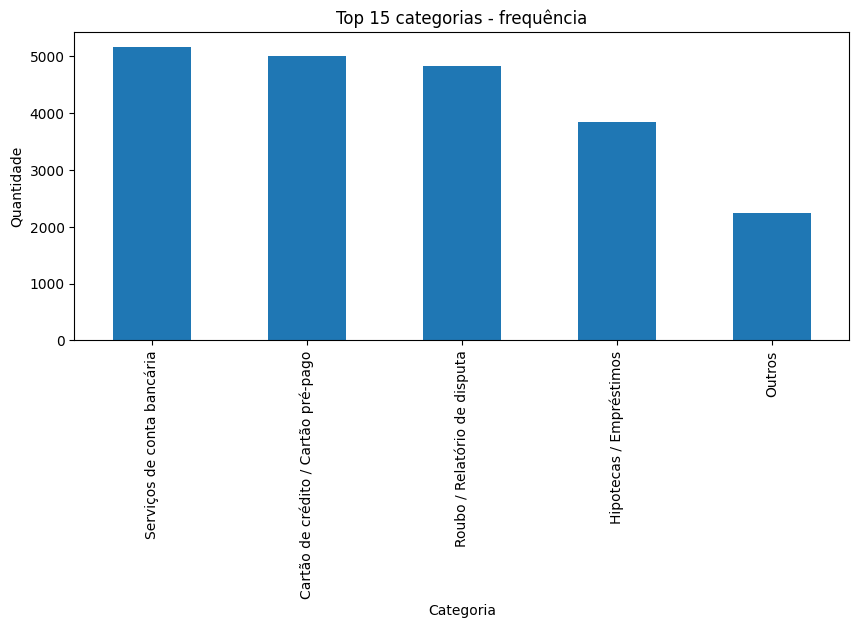

,categoria,descricao_reclamacao
10796,Serviços de conta bancária,Oxxxx xxxx pagou o JP Morgan Chase {$ 1200.00}...
16441,Roubo / Relatório de disputa,Perdi meu cartão de crédito (uma reserva de sa...
16623,Hipotecas / Empréstimos,"Em 2005, fui para xxxx xxxx xxxx. Eles me dire..."
12833,Roubo / Relatório de disputa,Eu me inscrevi e recebi um cartão de crédito p...
14844,Roubo / Relatório de disputa,"Com o Chase A {$ 620,00} Charge (xxxx 2015) fo..."


In [5]:
# Análise exploratória

# Checando nulos
display(df.isna().sum())

# Distribuição das categorias
top_classes = df['categoria'].value_counts().head(15)
display(top_classes)

# Plot top 15
plt.figure(figsize=(10,4))
top_classes.plot(kind='bar')
plt.title("Top 15 categorias - frequência")
plt.xlabel("Categoria")
plt.ylabel("Quantidade")
plt.show()

# Visualização de exemplos aleatórios de tickets da base de dados
display(df[['categoria','descricao_reclamacao']].sample(5, random_state=42))


## 4 Pré-processamento + Baseline com Vetorização (TF-IDF n-gram) e Modelo supervisionado

In [6]:
# Padronização/limpeza de texto
def basic_clean(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = unidecode(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [7]:
# Separação features e labels
X = df['descricao_reclamacao'].astype(str).apply(basic_clean)
y = df['categoria'].astype(str)


In [8]:
# Requisito: 75% treino / 25% teste, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [9]:
# Pipeline TF-IDF + Logistic Regression (baseline)
baseline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)),
    ('clf', LogisticRegression(max_iter=2000))
])


In [11]:
# Treinando e avaliando o modelo baseline
baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)


In [12]:
# F1 Score
f1 = f1_score(y_test, pred, average='weighted')
print("F1 Score:", f1)

# Relatório de classificação
print("\nClassificação:")
print(classification_report(y_test, pred))

F1 Score: 0.8875587485541236

Classificação:
                                     precision    recall  f1-score   support

Cartão de crédito / Cartão pré-pago       0.89      0.91      0.90      1252
            Hipotecas / Empréstimos       0.90      0.90      0.90       962
                             Outros       0.90      0.73      0.81       558
       Roubo / Relatório de disputa       0.87      0.88      0.87      1206
         Serviços de conta bancária       0.89      0.94      0.91      1290

                           accuracy                           0.89      5268
                          macro avg       0.89      0.87      0.88      5268
                       weighted avg       0.89      0.89      0.89      5268



## 5 Melhorando o modelo (TF-IDF + LinearSVC)"

In [13]:
# Pipeline TF-IDF + LinearSVC
pipe_svc = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LinearSVC())
])


In [14]:
# Grid simples
param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [1, 2, 3],
    'tfidf__max_df': [0.9, 0.95],
    'clf__C': [0.5, 1.0, 2.0],
}


In [15]:
# Realizando o Grid Search com validação cruzada
grid = GridSearchCV(
    pipe_svc,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)


In [16]:
# Treinando o modelo
grid.fit(X_train, y_train)

print("Melhor F1 (CV):", grid.best_score_)
print("Melhores parâmetros:", grid.best_params_)


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Melhor F1 (CV): 0.8965880432617551
Melhores parâmetros: {'clf__C': 0.5, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}


In [17]:
# Avaliando no conjunto de teste
best_model = grid.best_estimator_
pred_best = best_model.predict(X_test)

# Cálculo do F1 Score
f1_best = f1_score(y_test, pred_best, average='weighted')
print("\nF1 Score - TF-IDF + LinearSVC:", f1_best)
print("\nClassificação:")
print(classification_report(y_test, pred_best))


F1 Score - TF-IDF + LinearSVC: 0.9002029683300445

Classificação:
                                     precision    recall  f1-score   support

Cartão de crédito / Cartão pré-pago       0.90      0.91      0.90      1252
            Hipotecas / Empréstimos       0.92      0.90      0.91       962
                             Outros       0.89      0.84      0.86       558
       Roubo / Relatório de disputa       0.88      0.88      0.88      1206
         Serviços de conta bancária       0.91      0.93      0.92      1290

                           accuracy                           0.90      5268
                          macro avg       0.90      0.89      0.90      5268
                       weighted avg       0.90      0.90      0.90      5268



## 6 Modelo com Embeddings

In [18]:
# Classificador baseado em embeddings densos
torch.set_num_threads(2)

# Funções auxiliares para Word2Vec Skip-gram + Negative Sampling
def build_vocab(texts, min_count=8, max_vocab=20000):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = [w for w,c in counter.items() if c >= min_count]
    vocab = sorted(vocab, key=lambda w: counter[w], reverse=True)[:max_vocab-2]
    itos = ['<pad>', '<unk>'] + vocab
    stoi = {w:i for i,w in enumerate(itos)}
    return stoi, itos, counter

# Converte textos em índices
def texts_to_indices(texts, stoi):
    unk = stoi['<unk>']
    return [[stoi.get(w, unk) for w in t.split()] for t in texts]

# Gera pares (center, context) para Skip-gram
def generate_skipgram_pairs(seqs, window=2, max_pairs=40000):
    pairs = []
    for seq in seqs:
        n = len(seq)
        for i, center in enumerate(seq):
            start = max(0, i-window)
            end = min(n, i+window+1)
            for j in range(start, end):
                if j == i:
                    continue
                pairs.append((center, seq[j]))
                if len(pairs) >= max_pairs:
                    return np.array(pairs, dtype=np.int64)
    return np.array(pairs, dtype=np.int64)

# Modelo Skip-gram com Negative Sampling
class SkipGramNS(torch.nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.in_emb = torch.nn.Embedding(vocab_size, emb_dim)
        self.out_emb = torch.nn.Embedding(vocab_size, emb_dim)

    def forward(self, center, context, neg):
        v = self.in_emb(center)
        u_pos = self.out_emb(context)
        u_neg = self.out_emb(neg)

        pos_score = (v * u_pos).sum(dim=1)
        neg_score = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)
        return pos_score, neg_score


In [ ]:
# Treinamento do modelo Word2Vec Skip-gram + Negative Sampling
def train_word2vec(texts_train, emb_dim=50, window=2, min_count=8, epochs=1,
                   batch_size=4096, neg_k=3, lr=0.03, max_pairs=40000):
    stoi, itos, counter = build_vocab(texts_train, min_count=min_count)
    seqs = texts_to_indices(texts_train, stoi)
    pairs = generate_skipgram_pairs(seqs, window=window, max_pairs=max_pairs)

    vocab_size = len(itos)

    # distribuição negativa para negative sampling
    freqs = np.array([counter.get(w, 1) for w in itos], dtype=np.float64)
    freqs = freqs ** 0.75
    freqs = freqs / freqs.sum()

    model = SkipGramNS(vocab_size, emb_dim)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = torch.nn.BCEWithLogitsLoss()

    n_pairs = len(pairs)
    for ep in range(epochs):
        idx = np.random.permutation(n_pairs)
        total_loss = 0.0

        for start in range(0, n_pairs, batch_size):
            batch_idx = idx[start:start+batch_size]
            bc = pairs[batch_idx, 0]
            bctx = pairs[batch_idx, 1]
            neg = np.random.choice(vocab_size, size=(len(batch_idx), neg_k), p=freqs)

            center = torch.tensor(bc, dtype=torch.long)
            context = torch.tensor(bctx, dtype=torch.long)
            neg_t = torch.tensor(neg, dtype=torch.long)

            pos_score, neg_score = model(center, context, neg_t)
            loss_pos = bce(pos_score, torch.ones_like(pos_score))
            loss_neg = bce(neg_score, torch.zeros_like(neg_score))
            loss = loss_pos + loss_neg

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(batch_idx)

        print(f"Epoch {ep+1}/{epochs} - Loss médio: {total_loss/n_pairs:.4f}")

    return model, stoi


In [ ]:
# Treinando Word2Vec no conjunto de treino
w2v_model, w2v_stoi = train_word2vec(X_train.tolist())


Epoch 1/1 - Loss médio: 5.1504


In [21]:
# Classificador baseado em médias dos embeddings + LogisticRegression
class SentenceVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, w2v_model, stoi, emb_dim=50):
        self.w2v_model = w2v_model
        self.stoi = stoi
        self.emb_dim = emb_dim

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        unk = self.stoi.get('<unk>', 1)
        vecs = []
        for doc in X:
            idxs = [self.stoi.get(w, unk) for w in doc.split()]
            if len(idxs) == 0:
                vecs.append(np.zeros(self.emb_dim))
                continue
            emb = self.w2v_model.in_emb(torch.tensor(idxs, dtype=torch.long)).detach().numpy()
            vecs.append(emb.mean(axis=0))
        return np.vstack(vecs)


In [22]:
# Pipeline completo: SentenceVectorizer + LogisticRegression
w2v_clf = Pipeline([
    ('sent_vec', SentenceVectorizer(w2v_model, w2v_stoi, emb_dim=50)),
    ('clf', LogisticRegression(max_iter=2000))
])


In [23]:
# Treinando e avaliando o classificador Word2Vec + LogisticRegression
w2v_clf.fit(X_train, y_train)
pred_w2v = w2v_clf.predict(X_test)


In [24]:
# Cálculo do F1 Score
f1_w2v = f1_score(y_test, pred_w2v, average='weighted')
print("\nF1 Score (weighted) - Word2Vec (PyTorch) + LogisticRegression (TESTE):", f1_w2v)
print("\nClassification report:")
print(classification_report(y_test, pred_w2v))



F1 Score (weighted) - Word2Vec (PyTorch) + LogisticRegression (TESTE): 0.572114223092725

Classification report:
                                     precision    recall  f1-score   support

Cartão de crédito / Cartão pré-pago       0.60      0.63      0.61      1252
            Hipotecas / Empréstimos       0.56      0.52      0.54       962
                             Outros       0.54      0.35      0.42       558
       Roubo / Relatório de disputa       0.52      0.51      0.51      1206
         Serviços de conta bancária       0.63      0.74      0.68      1290

                           accuracy                           0.58      5268
                          macro avg       0.57      0.55      0.55      5268
                       weighted avg       0.57      0.58      0.57      5268



###**Validação do professor**

Consolidar apenas os scripts do seu **modelo campeão**, desde o carregamento do dataframe, separação das amostras, tratamentos utilizados (funções, limpezas, etc.), criação dos objetos de vetorização dos textos e modelo treinado e outras implementações utilizadas no processo de desenvolvimento do modelo.

O modelo precisar atingir um score na métrica F1 Score superior a 75%.

**Atenção:**
- **Implemente aqui apenas os scripts que fazem parte do modelo campeão.**
- **Execute o pipeline do modelo campeão completamente para garantir que não tetá erros no script.**


## Modelo campeão

In [1]:
# MODELO CAMPEÃO
# Do carregamento da base até a validação final

import pandas as pd
import re

from unidecode import unidecode
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report

# 1) Carregamento da base
df = pd.read_csv('https://dados-ml-pln.s3.sa-east-1.amazonaws.com/tickets_reclamacoes_classificados.csv', delimiter=';')

# 2) Limpeza do texto
def basic_clean(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = unidecode(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

X = df['descricao_reclamacao'].astype(str).apply(basic_clean)
y = df['categoria'].astype(str)

# 3) Split treino e teste 75%/25%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 4) Pipeline do modelo
campeao = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,1),
        min_df=1,
        max_df=0.9
    )),
    ('clf', LinearSVC(C=0.5))
])

# 5) Treinamento do modelo
campeao.fit(X_train, y_train)

# 6) Avaliação no conjunto de teste
pred = campeao.predict(X_test)

# Cálculo do F1 Score
f1 = f1_score(y_test, pred, average='weighted')
print("F1 Score:", f1)

print("\nClassificação:")
print(classification_report(y_test, pred))


F1 Score: 0.9002029683300445

Classificação:
                                     precision    recall  f1-score   support

Cartão de crédito / Cartão pré-pago       0.90      0.91      0.90      1252
            Hipotecas / Empréstimos       0.92      0.90      0.91       962
                             Outros       0.89      0.84      0.86       558
       Roubo / Relatório de disputa       0.88      0.88      0.88      1206
         Serviços de conta bancária       0.91      0.93      0.92      1290

                           accuracy                           0.90      5268
                          macro avg       0.90      0.89      0.90      5268
                       weighted avg       0.90      0.90      0.90      5268



In [2]:
# Salvando o modelo
import joblib

joblib.dump(campeao, "modelo_campeao.joblib")
print("Modelo salvo com sucesso!")

# Função de classificação de novos chamados
def classificar_chamado(texto):
    """
    Recebe um texto de chamado e retorna a categoria prevista
    """
    texto_limpo = basic_clean(texto)
    return campeao.predict([texto_limpo])[0]


Modelo salvo com sucesso!


In [3]:
# Teste do modelo com novos textos (simulação real)
exemplos = [
    "Meu cartão foi cobrado duas vezes e preciso de estorno",
    "Gostaria de renegociar meu empréstimo pessoal",
    "Minha conta bancária foi bloqueada sem aviso",
    "Fui vítima de fraude e preciso registrar disputa",
    "Tenho dúvidas sobre financiamento imobiliário"
]

for texto in exemplos:
    print("Texto:", texto)
    print("Categoria prevista:", classificar_chamado(texto))
    print("-" * 60)


Texto: Meu cartão foi cobrado duas vezes e preciso de estorno
Categoria prevista: Roubo / Relatório de disputa
------------------------------------------------------------
Texto: Gostaria de renegociar meu empréstimo pessoal
Categoria prevista: Hipotecas / Empréstimos
------------------------------------------------------------
Texto: Minha conta bancária foi bloqueada sem aviso
Categoria prevista: Serviços de conta bancária
------------------------------------------------------------
Texto: Fui vítima de fraude e preciso registrar disputa
Categoria prevista: Roubo / Relatório de disputa
------------------------------------------------------------
Texto: Tenho dúvidas sobre financiamento imobiliário
Categoria prevista: Hipotecas / Empréstimos
------------------------------------------------------------
